# EcoPlots Python Library - Use case 1 - Animal occurrence in North Queensland

This example showcases how to get the occurrences of animal species in North Queensland from the Williams Wet 
Tropics dataset (244k occurrences).

We get the most common recorded specie and we plot them in a map.

In [1]:
from terndata.ecoplots import EcoPlots
ecoplots = EcoPlots()

# Display the client information
print(ecoplots)

╔══════════════════════════════════════════════════════════════════════════════╗
║ EcoPlots                                                                     ║
║ Version: 0.0.4-beta                                                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║ No filters applied                                                           ║
╚══════════════════════════════════════════════════════════════════════════════╝


In [2]:

# Select animal occurrence data for the observed property "taxon"
ecoplots.select(feature_type="animal occurrence").select(observed_property="taxon")
# List available data sources
ecoplots.get_datasources()

,key,uri
0,Williams Wet Tropics Vertebrate database,http://linked.data.gov.au/dataset/wet-tropics-...


In [3]:
# Summarise the data before downloading it into a DataFrame
ecoplots.summarise_data()

{'total_doc': 244064,
 'unique_count': {'dataset': 1,
  'feature_type': 1,
  'observed_property': 1,
  'site': 0,
  'site_visit': 0}}

In [4]:
# Download the data into a DataFrame. By default, this will return a pandas DataFrame.
# The total ammount of data downloaded will be 244k rows. This may take a few moments.
df_animal = ecoplots.get_data()

In [5]:
# Display the first few rows of the DataFrame
df_animal.head()

,datasetTitle,latitude_Degree,longitude_Degree,featureType,featureId,scientificName,taxon,taxonResultTime,taxonMethod,geometry
0,Williams Wet Tropics Vertebrate database,-17.409718,145.980820,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Casuarius casuarius,https://biodiversity.org.au/afd/taxa/5fc1b9fe-...,2001-05-01T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (145.98082 -17.40972)
1,Williams Wet Tropics Vertebrate database,-16.069324,145.462097,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Casuarius casuarius,https://biodiversity.org.au/afd/taxa/5fc1b9fe-...,2007-01-19T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (145.4621 -16.06932)
2,Williams Wet Tropics Vertebrate database,-17.515404,145.512604,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Casuarius casuarius,https://biodiversity.org.au/afd/taxa/5fc1b9fe-...,1996-06-01T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (145.5126 -17.5154)
3,Williams Wet Tropics Vertebrate database,-17.855900,146.060898,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Casuarius casuarius,https://biodiversity.org.au/afd/taxa/5fc1b9fe-...,1997-07-21T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (146.0609 -17.8559)
4,Williams Wet Tropics Vertebrate database,-17.254171,145.637497,animal occurrence,http://linked.data.gov.au/dataset/wet-tropics-...,Podiceps cristatus australis,https://biodiversity.org.au/afd/taxa/9e378da7-...,1993-07-01T00:00:00,http://linked.data.gov.au/def/tern-cv/de94b8fd...,POINT (145.6375 -17.25417)


In [5]:
# Count occurrences of each scientific name, sorted in descending order (most frequent first)
df_animal['scientificName'].groupby(df_animal['scientificName']).count().sort_values(ascending=False)

scientificName
Cophixalus ornatus                     9844
Gerygone mouki mouki                   7491
Heteromyias cinereifrons               6666
Sericornis (Arfakornis) magnirostra    5810
Carlia rubrigularis                    5708
                                       ... 
Lampropholis adonis                       1
Lampropholis amicula                      1
Pygopus schraderi                         1
Ptilotula plumula planasi                 1
APODIDAE                                  1
Name: scientificName, Length: 587, dtype: int64

In [6]:
# Install required packages for plotting the data
%pip install matplotlib basemap

Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='longitude_Degree', ylabel='latitude_Degree'>

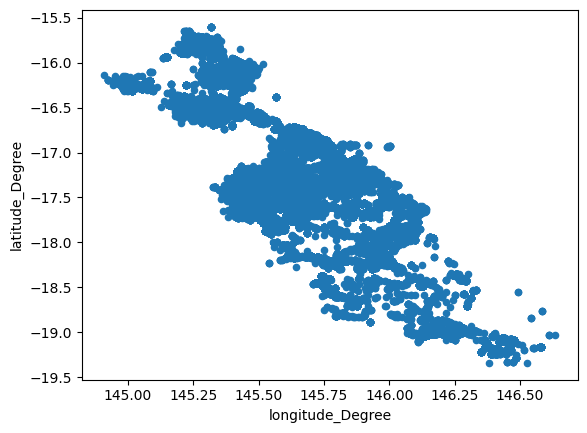

In [ ]:
df_animal.plot(x="longitude_Degree", y="latitude_Degree", kind="scatter")

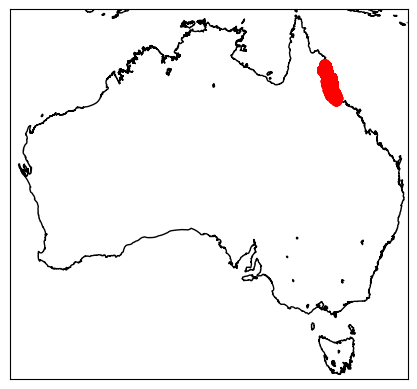

In [ ]:
from mpl_toolkits.basemap import Basemap
# import matplotlib.pyplot as plt

# create a map from Australia 
m = Basemap(projection='merc',llcrnrlat=-44,urcrnrlat=-10,\
            llcrnrlon=112,urcrnrlon=154,resolution='i')
# draw coastlines.
m.drawcoastlines()
# # convert latitude and longitude to x and y coordinates
x, y = m(df_animal['longitude_Degree'].values, df_animal['latitude_Degree'].values)
m.scatter(x, y, marker='o', color='Red', zorder=5)      
# plot map on axis
# plt.show()

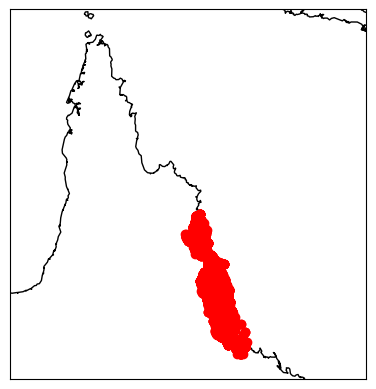

In [ ]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

# create a map from North Queensland, Australia
m = Basemap(projection='merc',llcrnrlat=-20,urcrnrlat=-10,\
            llcrnrlon=140,urcrnrlon=150,resolution='i')
# draw coastlines.
m.drawcoastlines()
# # convert latitude and longitude to x and y coordinates
x, y = m(df_animal['longitude_Degree'].values, df_animal['latitude_Degree'].values)
m.scatter(x, y, marker='o', color='Red', zorder=5)      
# plot map on axis
# plt.show()